### Blob detection

Image shape: (360, 360, 3)
Grayscale shape: (360, 360)

Sigma range: [1, 10]
Number of scales: 37

Building scale space...
Detection threshold: 0.0032 (max response: 0.3956)
Found 9046 blobs
Blobs after NMS: 4133


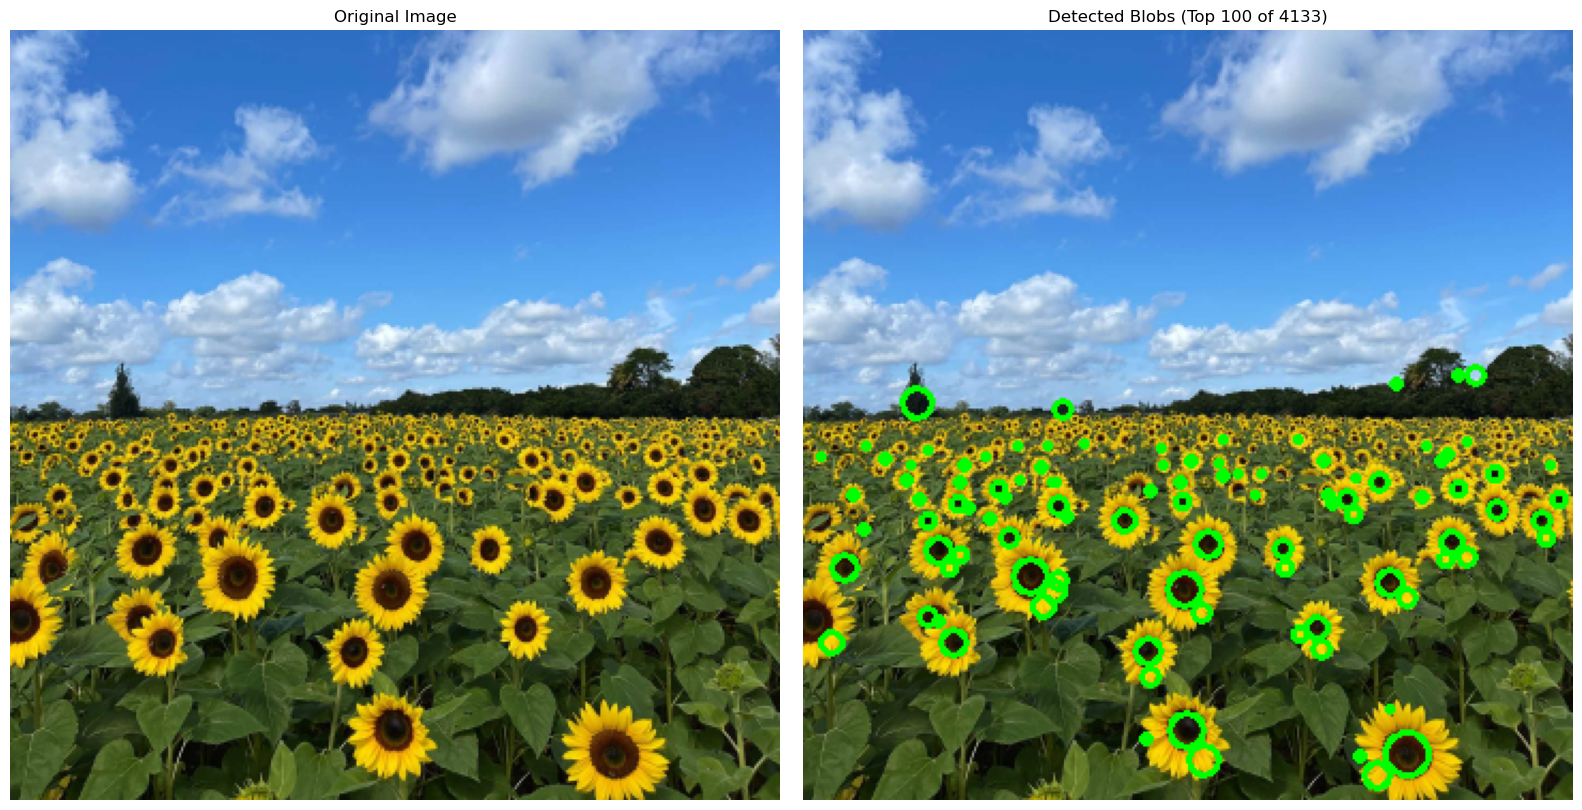


RESULTS

Sigma range used: [1.0, 10.0]
Number of scales: 37
Total blobs detected (after NMS): 4133

Top 10 Largest Circles (by sigma):
Rank   Y        X        Sigma      Radius     Response    
----------------------------------------------------------------------
1      48.0     121.0    9.50       13.44      0.1680      
2      166.0    33.0     9.50       13.44      0.1676      
3      157.0    201.0    9.50       13.44      0.1639      
4      24.0     220.0    9.50       13.44      0.1559      
5      69.0     24.0     9.50       13.44      0.1483      
6      18.0     287.0    9.50       13.44      0.0943      
7      159.0    335.0    9.25       13.08      0.1940      
8      326.0    144.0    9.25       13.08      0.1548      
9      302.0    192.0    9.25       13.08      0.1026      
10     94.0     18.0     9.25       13.08      0.0565      

Largest circle parameters:
  Center: (x=121.0, y=48.0)
  Sigma: 9.50
  Radius: 13.44 pixels
  Response strength: 0.1680

Creating zo

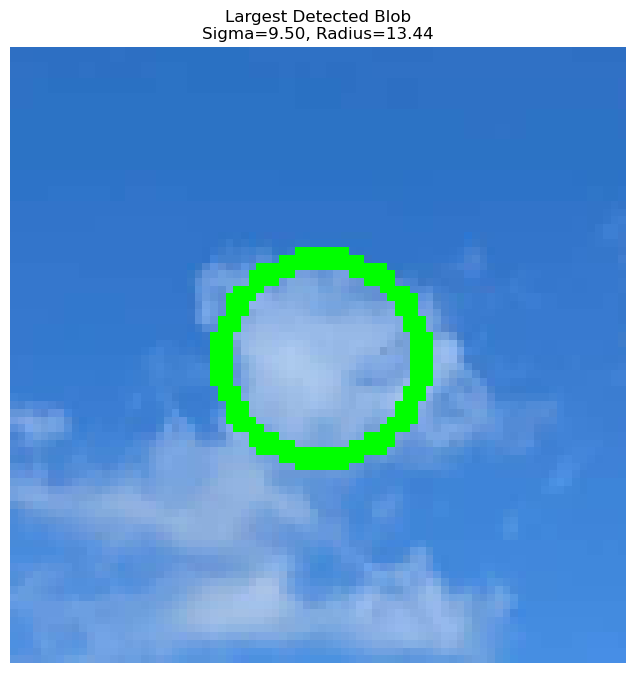

In [1]:
import cv2 as cv
import matplotlib.pyplot as plt
import numpy as np

# Loading image and converting to grayscale
im_bgr = cv.imread('the_berry_farms_sunflower_field.jpeg', cv.IMREAD_REDUCED_COLOR_4)
im_gray = cv.cvtColor(im_bgr, cv.COLOR_BGR2GRAY).astype(np.float32) / 255.0

h, w = im_gray.shape
print(f"Image shape: {im_bgr.shape}")
print(f"Grayscale shape: {im_gray.shape}")

# Selecting a sigma range
sigma_min, sigma_max, sigma_step = 1, 10, 0.25
sigmas = np.arange(sigma_min, sigma_max + sigma_step, sigma_step)
print(f"\nSigma range: [{sigma_min}, {sigma_max}]")
print(f"Number of scales: {len(sigmas)}")

scale_space = np.zeros((h, w, len(sigmas)), dtype=np.float32)

# Build scale space
print("\nBuilding scale space...")
for i, sigma in enumerate(sigmas):
    hw = round(3 * sigma)
    X, Y = np.meshgrid(np.arange(-hw, hw + 1), np.arange(-hw, hw + 1))
    
    # Laplacian of Gaussian filter
    LoG = (X**2 + Y**2 - 2 * sigma**2) * np.exp(-(X**2 + Y**2) / (2 * sigma**2))
    LoG /= 2 * np.pi * sigma**6
    
    # Normalizing the filter by sigma^2
    LoG *= sigma**2
    
    # Applying the filter
    im_LoG = cv.filter2D(im_gray, -1, LoG)
    
    # Storing the absolute value in the scale space
    scale_space[:, :, i] = np.abs(im_LoG)


def detect_scale_space_extrema(scale_space, sigmas, threshold=0.05):
    h, w, num_scales = scale_space.shape
    blobs = []
    
    # Threshold based on maximum response
    max_response = np.max(scale_space)
    abs_threshold = threshold * max_response
    print(f"Detection threshold: {abs_threshold:.4f} (max response: {max_response:.4f})")

    for scale_idx in range(1, num_scales - 1):
        current_scale = scale_space[:, :, scale_idx]
        prev_scale = scale_space[:, :, scale_idx - 1]
        next_scale = scale_space[:, :, scale_idx + 1]
        
        for i in range(1, h - 1):
            for j in range(1, w - 1):
                center_val = current_scale[i, j]
                
                if center_val < abs_threshold:
                    continue
                
                spatial_patch = current_scale[i-1:i+2, j-1:j+2]
                if center_val != np.max(spatial_patch):
                    continue
                
                if center_val <= prev_scale[i, j] or center_val <= next_scale[i, j]:
                    continue
                
                sigma = sigmas[scale_idx]
                blobs.append((i, j, sigma, center_val))
    
    return blobs

blobs = detect_scale_space_extrema(scale_space, sigmas, threshold=0.008)
print(f"Found {len(blobs)} blobs")


def non_maximum_suppression_blobs(blobs, overlap_threshold=0.5):
    blobs_sorted = sorted(blobs, key=lambda b: b[3], reverse=True)
    
    suppressed = []
    
    while len(blobs_sorted) > 0:
        current = blobs_sorted[0]
        suppressed.append(current)
        
        y1, x1, sigma1, response1 = current
        radius1 = np.sqrt(2) * sigma1
        
        remaining = []
        for blob in blobs_sorted[1:]:
            y2, x2, sigma2, response2 = blob
            radius2 = np.sqrt(2) * sigma2
            
            distance = np.sqrt((y1 - y2)**2 + (x1 - x2)**2)
            
            sum_radii = radius1 + radius2
            overlap = 1 - (distance / sum_radii)
            
            if overlap < overlap_threshold:
                remaining.append(blob)
        
        blobs_sorted = remaining
    
    return suppressed

blobs_nms = non_maximum_suppression_blobs(blobs, overlap_threshold=0.5)
print(f"Blobs after NMS: {len(blobs_nms)}")

fig, axes = plt.subplots(1, 2, figsize=(16, 8))

axes[0].imshow(cv.cvtColor(im_bgr, cv.COLOR_BGR2RGB))
axes[0].set_title('Original Image')
axes[0].axis('off')

result = im_bgr.copy()
num_to_draw = min(100, len(blobs_nms))
for i in range(num_to_draw):
    y, x, sigma, response = blobs_nms[i]
    
    # Radius = sqrt(2) * sigma for LoG
    radius = int(np.sqrt(2) * sigma)
    center = (int(x), int(y))
    
    # Draw circle
    cv.circle(result, center, radius, (0, 255, 0), 2)

axes[1].imshow(cv.cvtColor(result, cv.COLOR_BGR2RGB))
axes[1].set_title(f'Detected Blobs (Top {num_to_draw} of {len(blobs_nms)})')
axes[1].axis('off')

plt.tight_layout()
plt.savefig('sunflower_blob_detection.png', dpi=150, bbox_inches='tight')
plt.show()

# Report results
print("\n" + "="*70)
print("RESULTS")
print("="*70)
print(f"\nSigma range used: [{sigmas[0]}, {sigmas[-1]}]")
print(f"Number of scales: {len(sigmas)}")
print(f"Total blobs detected (after NMS): {len(blobs_nms)}")

print("\nTop 10 Largest Circles (by sigma):")
print(f"{'Rank':<6} {'Y':<8} {'X':<8} {'Sigma':<10} {'Radius':<10} {'Response':<12}")
print("-" * 70)

# Sort by sigma (size) for largest circles
blobs_by_size = sorted(blobs_nms, key=lambda b: b[2], reverse=True)

for i in range(min(10, len(blobs_by_size))):
    y, x, sigma, response = blobs_by_size[i]
    radius = np.sqrt(2) * sigma
    print(f"{i+1:<6} {y:<8.1f} {x:<8.1f} {sigma:<10.2f} {radius:<10.2f} {response:<12.4f}")

print("\nLargest circle parameters:")
y, x, sigma, response = blobs_by_size[0]
radius = np.sqrt(2) * sigma
print(f"  Center: (x={x:.1f}, y={y:.1f})")
print(f"  Sigma: {sigma:.2f}")
print(f"  Radius: {radius:.2f} pixels")
print(f"  Response strength: {response:.4f}")

# Zoomed view of largest blob
print("\nCreating zoomed view of largest blob...")
y_int, x_int = int(y), int(x)
crop_size = int(radius * 3)
y1 = max(0, y_int - crop_size)
y2 = min(h, y_int + crop_size)
x1 = max(0, x_int - crop_size)
x2 = min(w, x_int + crop_size)

cropped = im_bgr[y1:y2, x1:x2].copy()
center_in_crop = (x_int - x1, y_int - y1)
cv.circle(cropped, center_in_crop, int(radius), (0, 255, 0), 2)

plt.figure(figsize=(8, 8))
plt.imshow(cv.cvtColor(cropped, cv.COLOR_BGR2RGB))
plt.title(f'Largest Detected Blob\nSigma={sigma:.2f}, Radius={radius:.2f}')
plt.axis('off')
plt.savefig('largest_blob_zoom.png', dpi=150, bbox_inches='tight')
plt.show()



### Q2

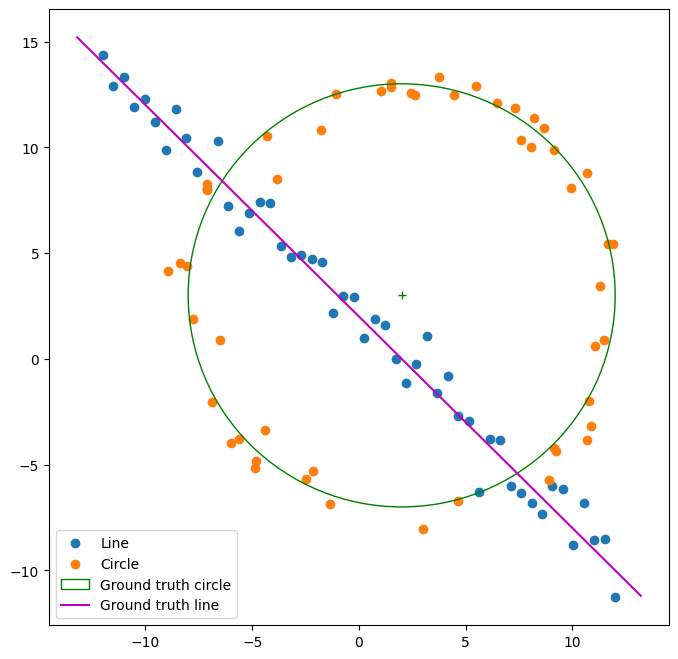

In [1]:
import numpy as np
from scipy . optimize import minimize
from scipy import linalg
import matplotlib.pyplot as plt
# import tikzplotlib
# np.random.seed(0)

N = 100 # number of points
half_n = N // 2
r = 10
x0_gt, y0_gt = 2, 3  # Circle center
s = r / 16

t = np.random.uniform(0, 2 * np.pi, half_n)
n = s * np.random.randn(half_n)
x, y = x0_gt + (r + n) * np.cos(t), y0_gt + (r + n) * np.sin(t)
X_circ = np.hstack((x.reshape(half_n, 1), y.reshape(half_n, 1)))

s = 1.0
m, c = -1, 2
x = np.linspace(-12, 12, half_n)
y = m * x + c + s * np.random.randn(half_n)
X_line = np.hstack((x.reshape(half_n, 1), y.reshape(half_n, 1)))
X = np.vstack((X_circ, X_line))  # All points

fig, ax = plt.subplots(1, 1, figsize=(8, 8))
ax.scatter(X_line[:, 0], X_line[:, 1], label='Line')
ax.scatter(X_circ[:, 0], X_circ[:, 1], label='Circle')
circle_gt = plt.Circle((x0_gt, y0_gt), r, color='g', fill=False, label='Ground truth circle')
ax.add_patch(circle_gt)
ax.plot((x0_gt), (y0_gt), '+', color='g')
x_min, x_max = ax.get_xlim()
x_ = np.array([x_min, x_max])
y_ = m * x_ + c
plt.plot(x_, y_, color='m', label='Ground truth line')
plt.legend()
plt.show()


In [34]:
def fit_line_TLS(points):
    x_mean, y_mean = np.mean(points, axis=0)
    U = points - np.array([x_mean, y_mean])
    _, _, Vt = linalg.svd(np.transpose(U)@U) # Single Value Decomposition
    a, b = Vt[-1] 
    norm = np.sqrt(a**2 + b**2)
    a, b = a / norm, b / norm # unit normal vector
    d = a * x_mean + b * y_mean
    return a, b, d


def ransac_line(X, n_iters=2000, threshold=0.7, min_inliers=35):
    best_inliers = [] # largest set of inliers
    best_param = None # best line parameters

    for _ in range(n_iters):
        idx = np.random.choice(X.shape[0], 2, replace=False) # picking 2 random points
        sample = X[idx]
        a, b, d = fit_line_TLS(sample)
        # Apply threshold to find inliers
        distances = np.abs(a * X[:, 0] + b * X[:, 1] - d)
        inliers = np.where(distances < threshold)[0]

        if len(inliers) > len(best_inliers): # choose the model witht the largest set of inliers
            best_inliers = inliers
            best_param = (a, b, d)

    if best_param is not None and len(best_inliers) > min_inliers: # refit best model with all the inliers
        a, b, d = fit_line_TLS(X[best_inliers])
        return a, b, d, best_inliers
        
    return None, None, None, [] # no line found


def circle_from_3pts(pts):
    A = np.bmat([[2 * (pts[1] - pts[0])], [2 * (pts[2] - pts[0])]]).reshape(2, 2)
    b = np.array([
        np.dot(pts[1], pts[1]) - np.dot(pts[0], pts[0]),
        np.dot(pts[2], pts[2]) - np.dot(pts[0], pts[0])
    ])
    # if A is singular, the points are collinear, so we cannot fit a circle
    center = np.linalg.solve(A, b)
    r = np.linalg.norm(center - pts[0])
    return center[0], center[1], r

def ransac_circle(X, n_iter=500, threshold=0.6, min_inliers=35):
    best_inliers = []
    best_params = None
    for _ in range(n_iter):
        idx = np.random.choice(len(X), 3, replace=False)
        sample = X[idx]
        # Skip nearly collinear samples, using the area of the triangle they form
        area = np.abs(np.cross(sample[1]-sample[0], sample[2]-sample[0]))
        if area < 1e-2:
            continue
        try:
            xc, yc, r = circle_from_3pts(sample)
        except np.linalg.LinAlgError: # due to collinearity
            continue
        err = np.abs(np.sqrt((X[:, 0] - xc)**2 + (X[:, 1] - yc)**2) - r)
        inliers = np.where(err < threshold)[0]
        if len(inliers) > len(best_inliers):
            best_inliers = inliers
            best_params = (xc, yc, r)

    if best_params is not None and len(best_inliers) > min_inliers:
        xc, yc, r = circle_from_3pts(X[best_inliers][:3]) # refit using first 3 inliers
        best_params = (xc, yc, r)
        
    return best_params, best_inliers


# refinement with scipy.optimize.minimize
def circle_residuals(params, points):
    xc, yc, r = params
    residuals = np.sqrt((points[:, 0] - xc)**2 + (points[:, 1] - yc)**2) - r
    return np.sum(residuals**2)

In [35]:
a, b, d, line_inliers = ransac_line(X)
X_rem = np.delete(X, line_inliers, axis=0) # remove line inliers

circle_params, circle_inliers = ransac_circle(X_rem)
xc, yc, r = circle_params
X_inliers = X_rem[circle_inliers]

residuals = minimize(circle_residuals, (xc, yc, r), args=(X_inliers,))
xc, yc, r = residuals.x

In [36]:
print(a, b, d)
print(xc, yc, r)

0.6997238515655936 0.7144134178122715 1.3160806831108425
1.8984035359396099 2.669530435164421 10.113981421667516


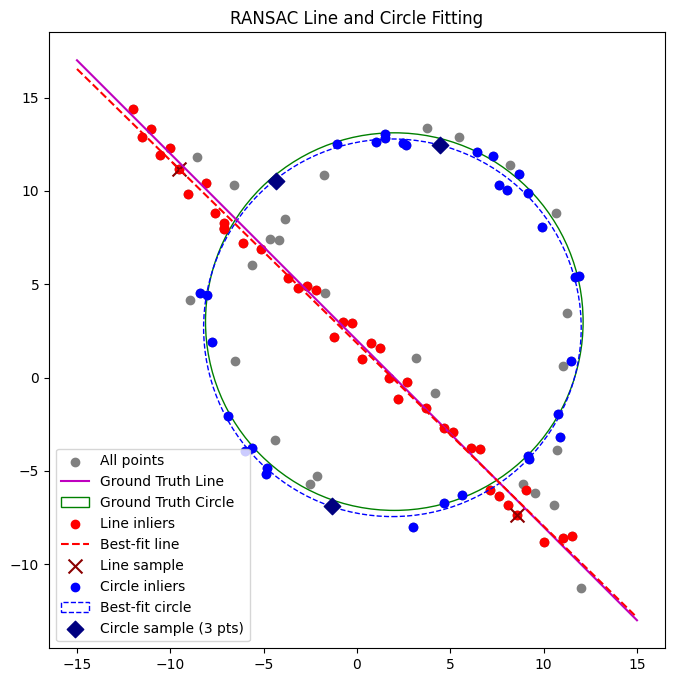

In [37]:
fig, ax = plt.subplots(figsize=(8, 8))
ax.scatter(X[:, 0], X[:, 1], color='gray', label='All points')

# Ground truth line and circle
x_range = np.linspace(-15, 15, 100)
y_gt = m * x_range + c
ax.plot(x_range, y_gt, 'm-', label='Ground Truth Line')
circle_gt = plt.Circle((x0_gt, y0_gt), r, color='g', fill=False, linestyle='-', label='Ground Truth Circle')
ax.add_patch(circle_gt)

# Line inliers and best-fit line
ax.scatter(X[line_inliers, 0], X[line_inliers, 1], color='red', label='Line inliers')
x_line = np.linspace(-15, 15, 100)
y_line = (d - a * x_line) / b
ax.plot(x_line, y_line, 'r--', label='Best-fit line')

sample_line_pts = X[np.random.choice(line_inliers, 2, replace=False)]
ax.scatter(sample_line_pts[:,0], sample_line_pts[:,1], color='darkred', marker='x', s=100, label='Line sample')

# Circle inliers and best-fit circle
if circle_params is not None:
    ax.scatter(X_rem[circle_inliers, 0], X_rem[circle_inliers, 1],
               color='blue', label='Circle inliers')
    circle_plot = plt.Circle((xc, yc), r, color='b', fill=False,
                             linestyle='--', label='Best-fit circle')
    ax.add_patch(circle_plot)

    sample_circle_pts = X_rem[np.random.choice(circle_inliers, 3, replace=False)]
    ax.scatter(sample_circle_pts[:,0], sample_circle_pts[:,1], color='navy', marker='D', s=70, label='Circle sample (3 pts)')

ax.set_aspect('equal', adjustable='box')
ax.legend()
plt.title('RANSAC Line and Circle Fitting')
plt.show()

### Q3

In [16]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

base_path_A = "../../images/ad_space.jpg"   
overlay_path_A = "../../images/poster.png"

base_path_B = "../../images/ad_space.jpg"   
overlay_path_B = "../../images/top_gun.png"   

save_dir = Path("homography_outputs_opencv")
save_dir.mkdir(parents=True, exist_ok=True)

In [17]:
def imread_color(p):
    img = cv2.imread(str(p), cv2.IMREAD_COLOR)
    if img is None:
        raise FileNotFoundError(p)
    return img

def click_four_points(img_bgr, window_name="Click TL, TR, BR, BL; 'r' reset; 'Esc' to quit"):
    pts = []

    disp = img_bgr.copy()
    cv2.namedWindow(window_name, cv2.WINDOW_NORMAL)

    def on_mouse(event, x, y, flags, param):
        if event == cv2.EVENT_LBUTTONDOWN and len(pts) < 4:
            pts.append((x, y))
            cv2.circle(disp, (x, y), 7, (0, 255, 0), -1)
            # cv2.putText(disp, str(len(pts)), (x + 8, y - 8),
                        # cv2.FONT_HERSHEY_SIMPLEX, 0.8, (0, 200, 0), 2)

    cv2.setMouseCallback(window_name, on_mouse)

    while True:
        cv2.imshow(window_name, disp)
        key = cv2.waitKey(20) & 0xFF
        if key == 27:  # Esc: abort
            cv2.destroyWindow(window_name)
            raise KeyboardInterrupt("User cancelled")
        if key == ord('r'):  # reset
            disp = img_bgr.copy()
            pts.clear()
        if len(pts) == 4:
            break

    cv2.destroyWindow(window_name)
    return np.array(pts, dtype=np.float32)

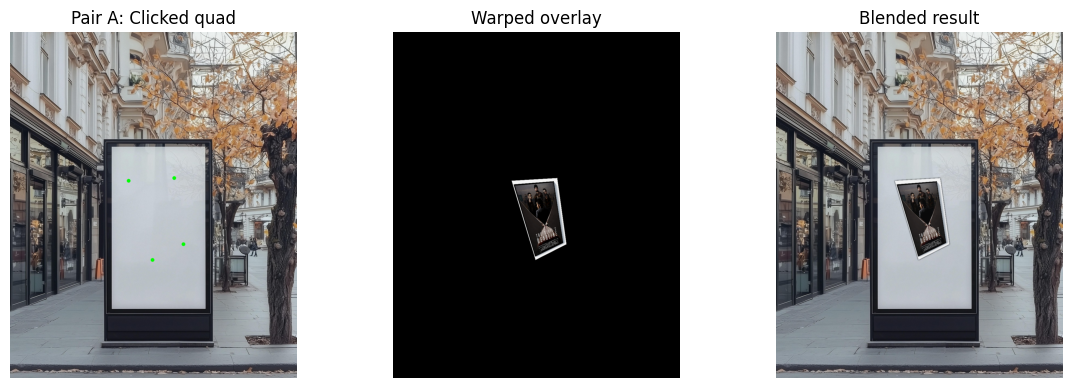

[Saved] homography_outputs_opencv\pair_A_warped.png
[Saved] homography_outputs_opencv\pair_A_blended.png


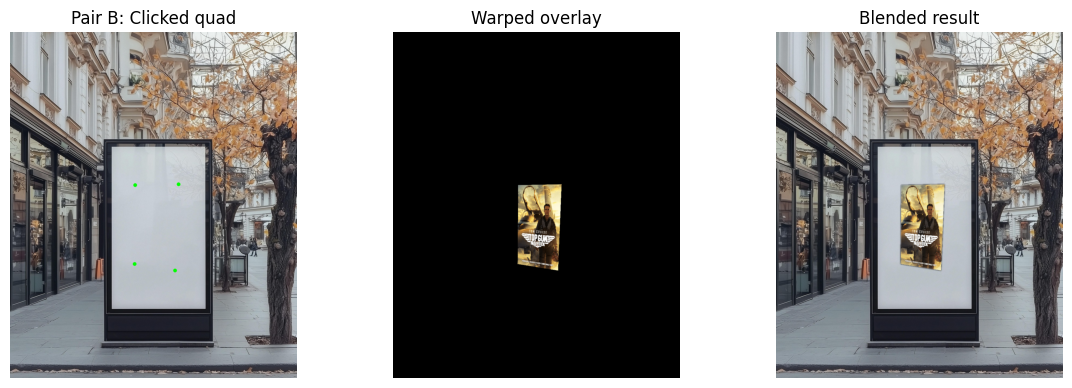

[Saved] homography_outputs_opencv\pair_B_warped.png
[Saved] homography_outputs_opencv\pair_B_blended.png


In [ ]:
def warp(base_img, dst_pts, use_findHomography=False):
    H_out, W_out = output_hw  
    h, w = base_img.shape[:2]
    src_pts = np.array([[0,0],[w-1,0],[w-1,h-1],[0,h-1]], np.float32)
    if use_findHomography:
        H, _ = cv2.findHomography(src_pts, dst_pts, method=0)  # least squares
    else:
        H = cv2.getPerspectiveTransform(src_pts, dst_pts)       # exact for 4 points
    warped = cv2.warpPerspective(base_img, H, (W_out, H_out),
                                 flags=cv2.INTER_LINEAR,
                                 borderMode=cv2.BORDER_CONSTANT,
                                 borderValue=(0,0,0))
    return warped

def build_paste_mask(dst_pts, feather=11, opacity=0.95):
    H_out, W_out = output_hw
    mask = np.zeros((H_out, W_out), np.uint8)
    cv2.fillConvexPoly(mask, dst_pts.astype(np.int32), 255)
    if feather and feather % 2 == 1:
        mask = cv2.GaussianBlur(mask, (feather, feather), 0)
    alpha = (mask.astype(np.float32)/255.0) * float(opacity)
    return alpha

def blend_over(base_bgr, warped_bgr, alpha):
    a3 = alpha[..., None]
    out = a3*(warped_bgr.astype(np.float32)/255.0) + (1.0-a3)*(base_bgr.astype(np.float32)/255.0)
    return (np.clip(out, 0, 1)*255).astype(np.uint8)

def run_pair(base_path, overlay_path, tag):
    # Load images
    base_bgr = imread_color(base_path)
    overlay_bgr = imread_color(overlay_path)
    global output_hw
    output_hw = base_bgr.shape[:2]  # (H, W)

    # Click 4 destination points TL,TR,BR,BL
    dst_pts = click_four_points(base_bgr, f"Pair {tag}: Click TL, TR, BR, BL")

    # Warp overlay to destination quad
    warped_overlay = warp(overlay_bgr, dst_pts)
    alpha = build_paste_mask(dst_pts, feather=11, opacity=0.95)
    blended = blend_over(base_bgr, warped_overlay, alpha)

    # Show + Save
    ann = base_bgr.copy()
    for i,(x,y) in enumerate(dst_pts.astype(int),1):
        cv2.circle(ann,(x,y),7,(0,255,0),-1)

    plt.figure(figsize=(14,4.5))
    plt.subplot(1,3,1); plt.imshow(cv2.cvtColor(ann, cv2.COLOR_BGR2RGB)); plt.axis('off'); plt.title(f"Pair {tag}: Clicked quad")
    plt.subplot(1,3,2); plt.imshow(cv2.cvtColor(warped_overlay, cv2.COLOR_BGR2RGB)); plt.axis('off'); plt.title("Warped overlay")
    plt.subplot(1,3,3); plt.imshow(cv2.cvtColor(blended, cv2.COLOR_BGR2RGB)); plt.axis('off'); plt.title("Blended result")
    plt.tight_layout
    plt.show()

    out_warped  = save_dir / f"pair_{tag}_warped.png"
    out_blended = save_dir / f"pair_{tag}_blended.png"
    cv2.imwrite(str(out_warped),  warped_overlay)
    cv2.imwrite(str(out_blended), blended)
    print(f"[Saved] {out_warped}")
    print(f"[Saved] {out_blended}")


run_pair(base_path_A, overlay_path_A, tag="A")
run_pair(base_path_B, overlay_path_B, tag="B")


In [ ]:
def compute_homography(src_points, dst_points):
    n = len(src_points)
    A = []
    
    # Build matrix A
    for i in range(n):
        x, y = src_points[i]
        x_p, y_p = dst_points[i]
        
        A.append([0, 0, 0, -x, -y, -1, y_p*x, y_p*y, y_p])
        A.append([x, y, 1, 0, 0, 0, -x_p*x, -x_p*y, -x_p])
    
    A = np.array(A)
    
    # Solve using SVD
    U, S, Vt = np.linalg.svd(A)
    h = Vt[-1, :]
    
    H = h.reshape(3, 3)
    H = H / H[2, 2]
    
    print(f"Points: {n}, Matrix A: {A.shape}")
    print(f"Smallest singular value: {S[-1]:.6e}")
    print("\nHomography H:")
    print(H)
    
    return H


def warp_image(image, H, output_shape):
    h, w = output_shape
    warped = cv2.warpPerspective(image, H, (w, h), flags=cv2.INTER_LINEAR)
    
    mask = cv2.cvtColor(warped, cv2.COLOR_BGR2GRAY)
    mask = (mask > 0).astype(np.uint8) * 255
    
    print(f"Output shape: {warped.shape}")
    print(f"Valid pixels: {np.sum(mask > 0)} / {h*w}")
    
    return warped, mask


### Q4